## 🧩 Substation Clustering

**Concepts:** [Ring semantics](../problem.md#ring-semantics) · [Meta-heuristics](../routers.md#meta-heuristics) · [Exact optimization](../routers.md#exact-optimization) **Reference:** [Validation](../reference/validation.md)

Creating the network for location with multiple roots introduces an additional layer to the network design problem: the partitioning of the terminals into per-root clusters. This new layer may be either solved before the network layer or jointly with it. _OptiWindNet_'s constructive heuristics and MILP models solve them jointly, while the meta-heuristics solve the partitioning first via [clusterize()](../autoapi/optiwindnet/clustering/index.rst#optiwindnet.clustering.clusterize) and then multiple single-root network design problems.

This notebook presents the automatic partitioning performed within [hgs_cvrp()](../autoapi/optiwindnet/baselines/hgs/index.rst#optiwindnet.baselines.hgs.hgs_cvrp) and [lkh3()](../autoapi/optiwindnet/baselines/lkh/index.rst#optiwindnet.baselines.lkh.lkh3) and an example of how to explicitly apply the same approach to MILP solvers.

### Automatic clustering: what the meta-heuristics already do

The meta-heuristics solve a _single-depot_ vehicle routing problem — one depot, many vehicles. So when they are given a multi-root instance, their wrappers partition the terminals first and hand each underlying meta-heuristic call one cluster, one depot, on its own.

This is a large part of why meta-heuristic results on multi-root locations are generally of poorer quality than the single-root results. The partition is fixed **before any link is chosen**, from a proxy — how far each terminal sits from each root — and it is never revisited. No terminal can migrate to a neighboring root during the search, however much that would improve the objective.

### No clustering: what the MILP does instead

The MILP model carries no such restriction. It is handed every root at once and decides the terminal-to-root assignment _as part of_ the optimization, jointly with the links, the loads and the feeders. Nothing is frozen in advance, which enables an unclustered MILP solution to achieve a lower total length than what the meta-heuristics possibly could.

That advantage comes with a side-effect for ringed networks: for a multi-root instance, the solver is free to build a ring that has two different roots as end-points. Electrically this is a cable bridging two substations (which are implicitly electrically interconnected). It is legal in the model and it is often attractive on both length and redundancy — see [Ring semantics](../problem.md#ring-semantics).

### Multi-root clustering for MILP

The recipe modifies the MILP solving process to impose the constraint **every ring anchored to a single root** on the solution network. It uses [clusterize()](../autoapi/optiwindnet/clustering/index.rst#optiwindnet.clustering.clusterize) to split the model into multiple single-root models, solves those independently, and merges the results into one topology.

The drawback is the same faced by the meta-heuristics' two-layered approach — a partition frozen before optimization, and therefore a possibly higher total network length than the jointly solved problem may achieve.

Everything here uses the Advanced API directly; nothing below is a supported library function, and the merging step in particular reaches into graph internals that the solvers normally own.

### Load Modules & Data

In [1]:
from concurrent.futures import ThreadPoolExecutor

import networkx as nx
import numpy as np

from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.clustering import clusterize
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import (
    G_from_S,
    as_normalized,
    rings_from_S,
    validate_routeset,
    validate_topology,
)
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.svg import svgplot

_Neart na Gaoithe_ has two substations, which is the smallest instance that can show the effect. The `ringed` topology and a capacity of 4 make cross-root rings likely enough to observe reliably.

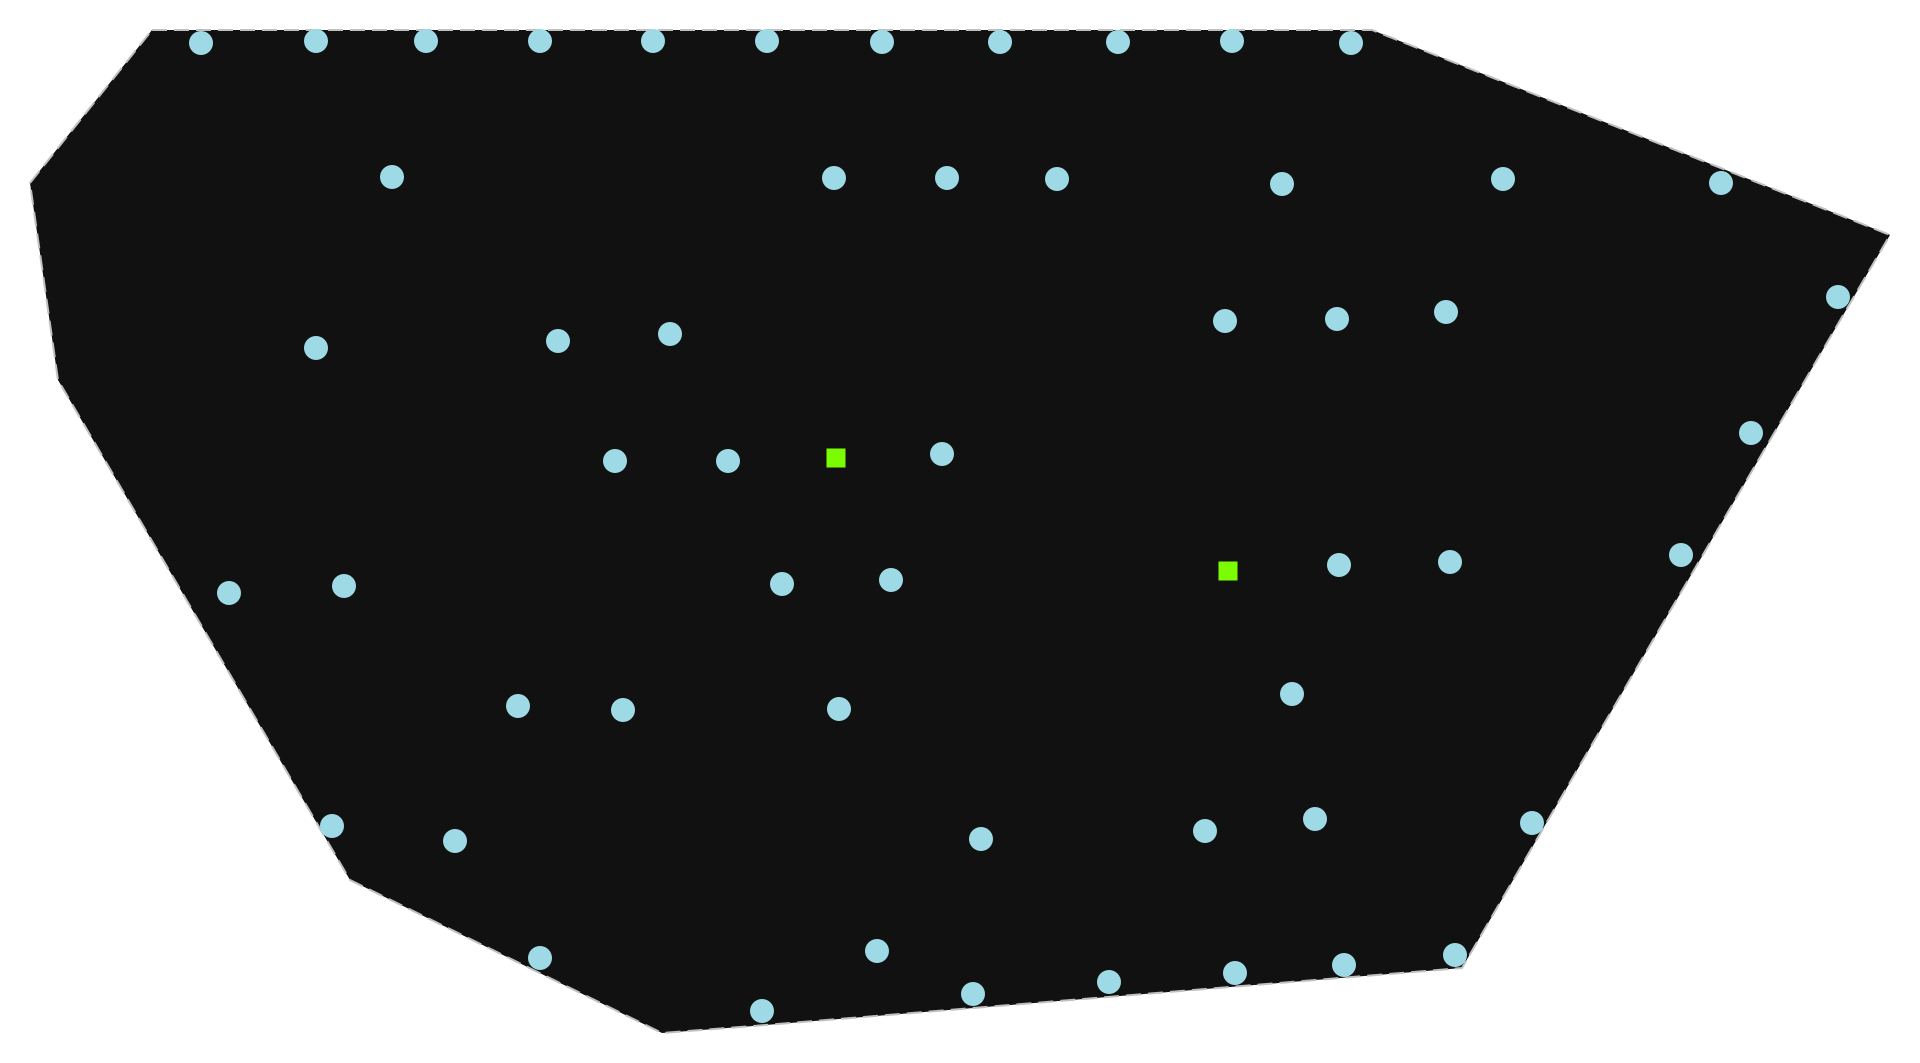

In [2]:
L = load_repository().neart
P, A = make_planar_embedding(L)
A_ = as_normalized(A)

capacity = 4
solver_name = 'ortools.cp_sat'
time_limit = 20
model_options = ModelOptions(topology='ringed')

svgplot(L)

### 1. The partition the meta-heuristics would use

[clusterize()](../autoapi/optiwindnet/clustering/index.rst#optiwindnet.clustering.clusterize) returns one set of terminals per root. Calling it explicitly here shows the partition that a meta-heuristic run on this instance would have applied silently — and that the MILP, left alone, would ignore.

cluster sizes: [23, 31]


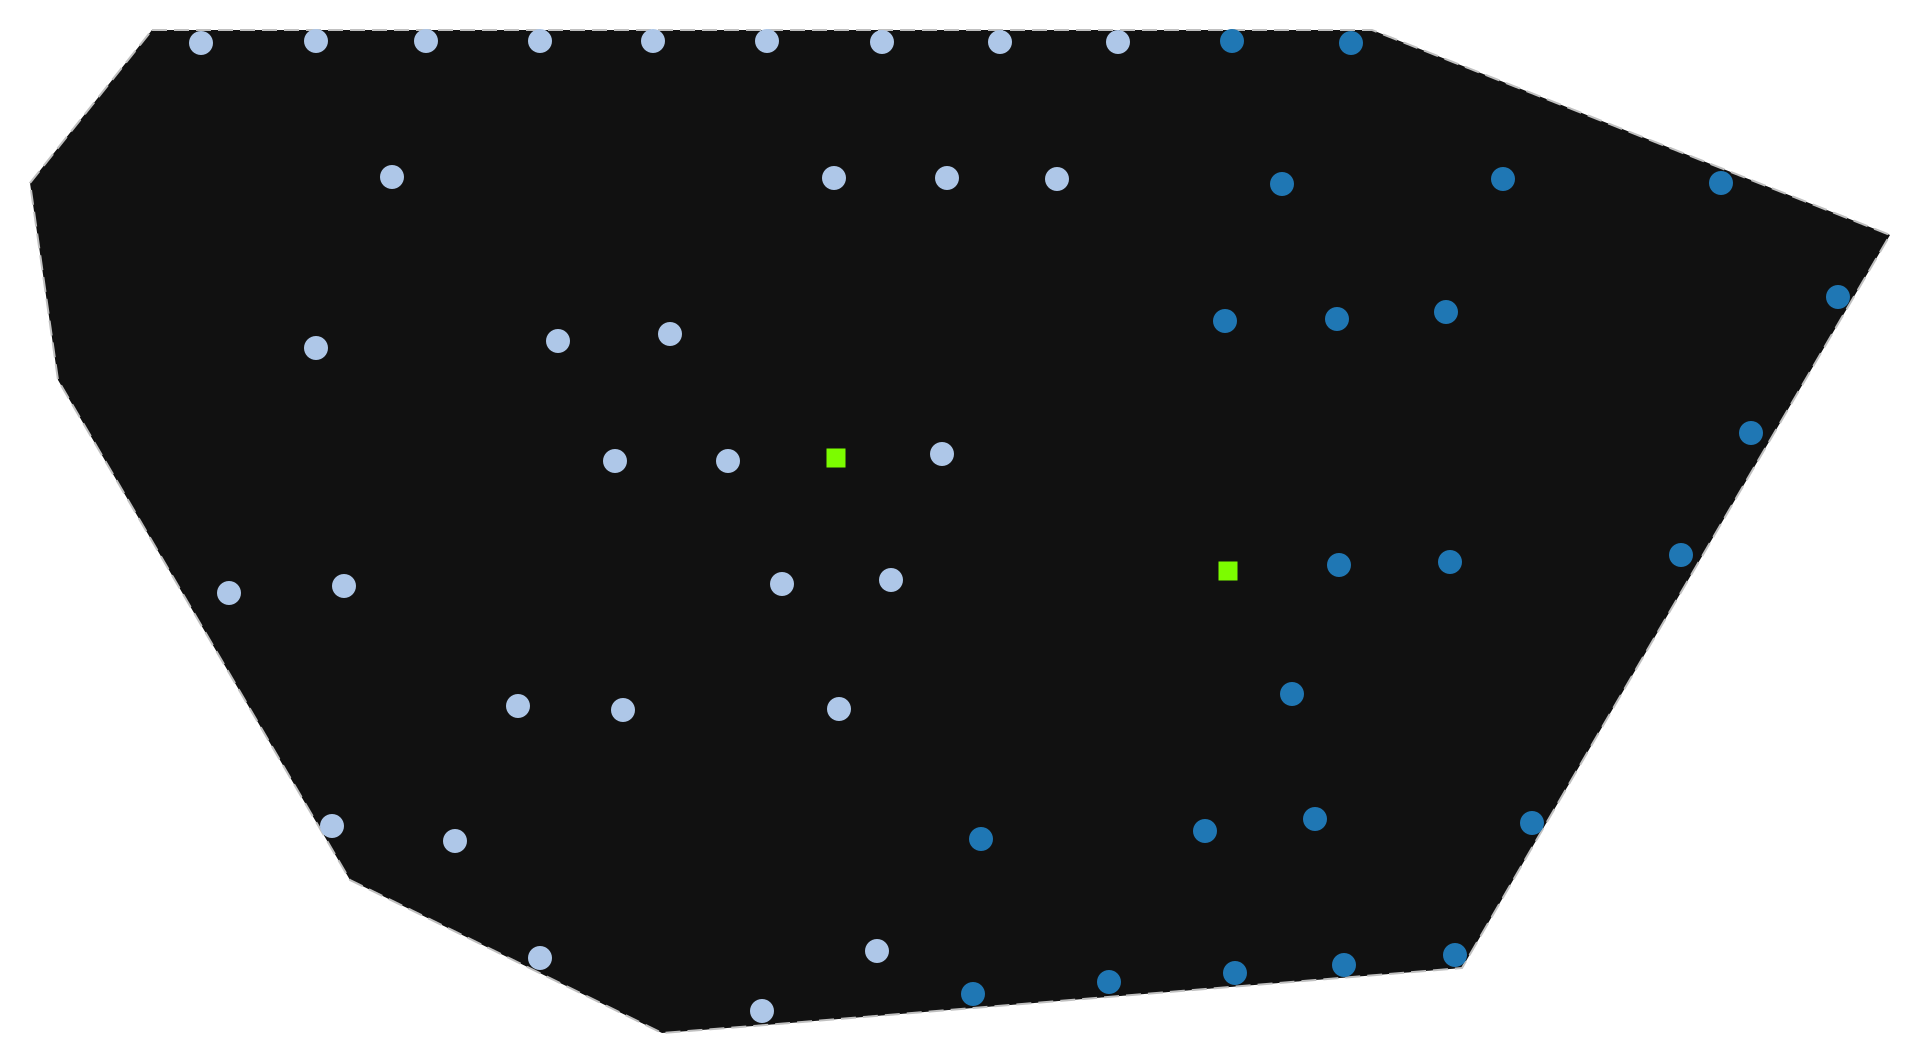

In [3]:
clusters = clusterize(A_, capacity)
print(f'cluster sizes: {[len(cluster) for cluster in clusters]}')

L_clusters = L.copy()
nx.set_node_attributes(
    L_clusters,
    {t: c for c, cluster in enumerate(clusters) for t in cluster},
    name='subtree',
)
svgplot(L_clusters)

### 2. The unclustered MILP, and its cross-root rings

Solving the instance as it stands lets the model assign terminals to substations on its own. [rings_from_S()](../autoapi/optiwindnet/interarraylib/index.rst#optiwindnet.interarraylib.rings_from_S) recovers each ring as `((r1, r2), [terminals])`; a ring with `r1 != r2` leaves one substation and arrives at another.

In [4]:
solver = solver_factory(solver_name)
solver.set_problem(P, A_, capacity, model_options)
solver.solve(time_limit=time_limit, mip_gap=0.0)
S_plain = solver.get_incumbent_topology()

cross-root rings: [(-2, -1), (-2, -1)]


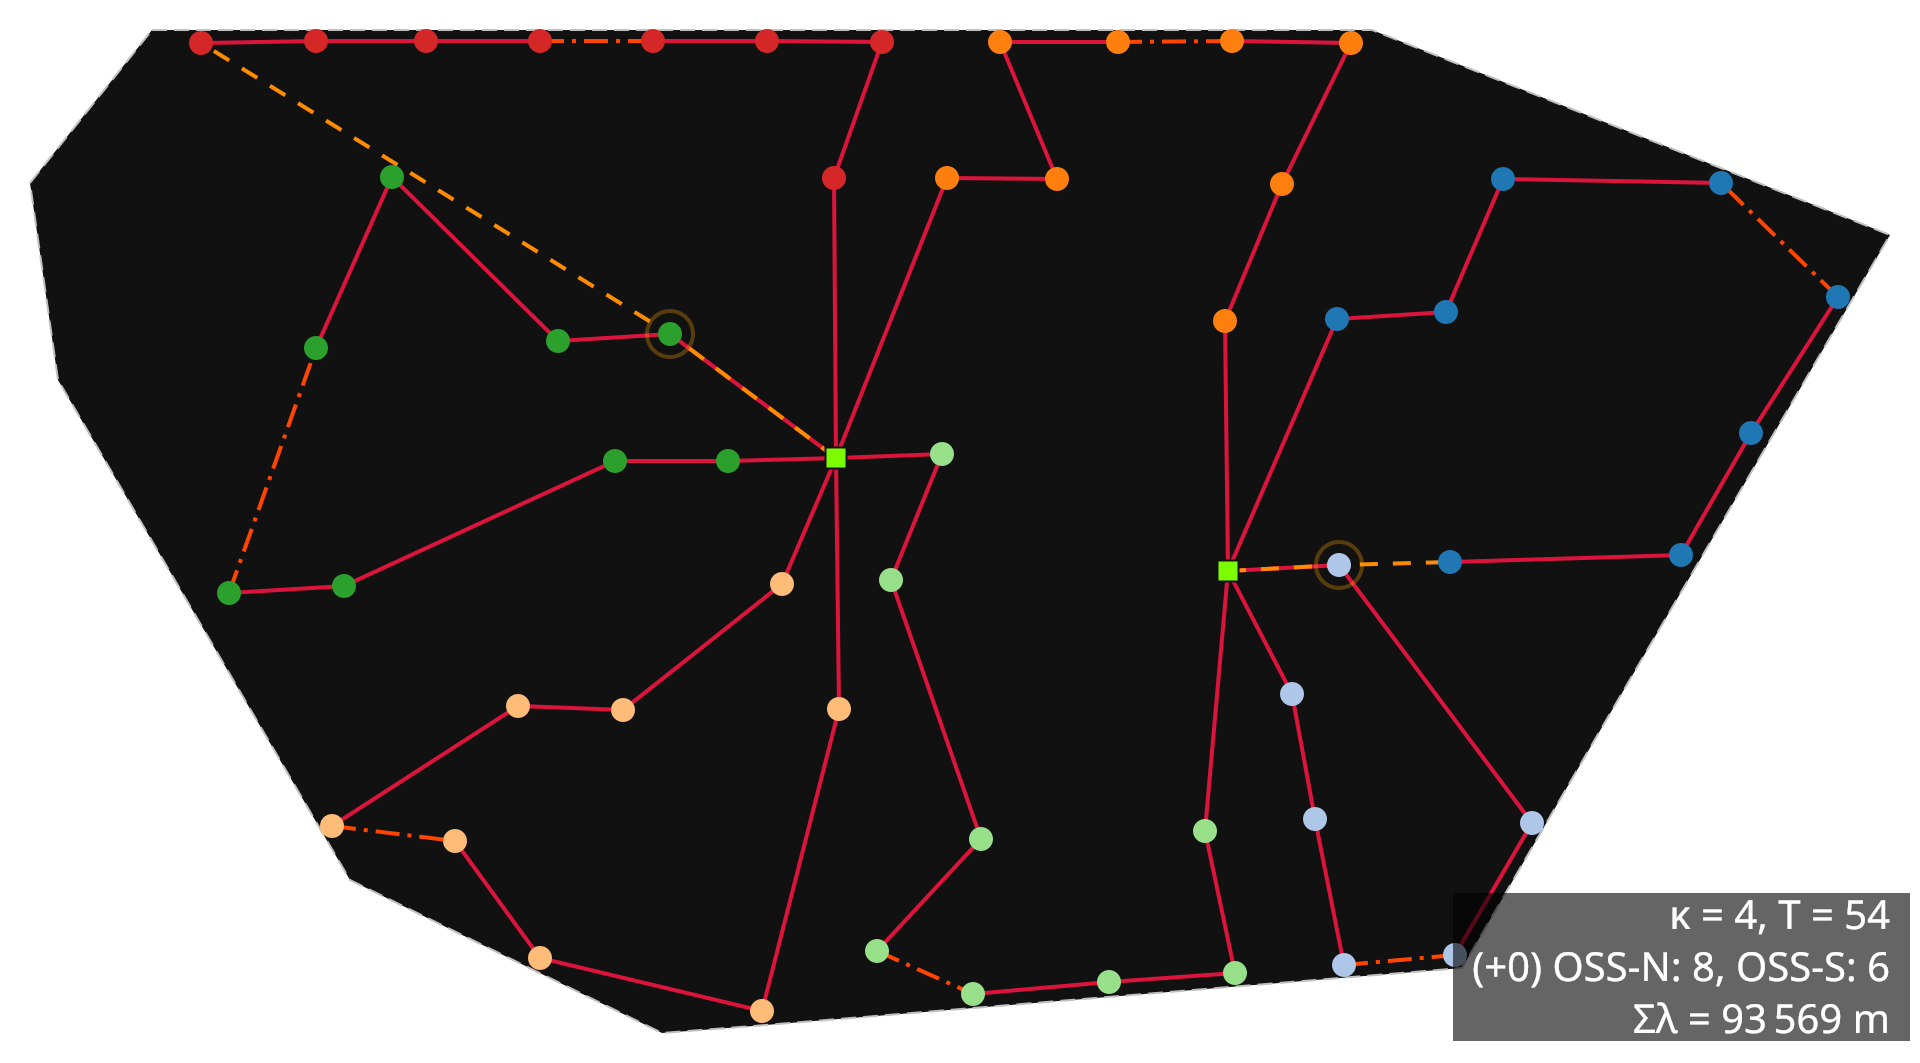

In [5]:
def cross_root_rings(S):
    return [roots for roots, _ in rings_from_S(S) if roots[0] != roots[1]]


print('cross-root rings:', cross_root_rings(S_plain))

G_plain = PathFinder(G_from_S(S_plain, A), planar=P, A=A).create_detours()
svgplot(G_plain)

### 3. Turning a cluster into a single-root problem

Each cluster becomes its own available-links graph, with its terminals renumbered `0..T_c-1` and its root renumbered `-1`, so that the model sees an ordinary single-substation instance.

Only the terminal-terminal entries of `diagonals` are carried over: those are what the model's edge-crossing constraints read, while feeder crossings are derived geometrically.

In [6]:
def single_root_subproblem(A, cluster, c):
    """Relabel one cluster into a standalone single-root available-links graph."""
    R = A.graph['R']
    VertexC, d2roots, diagonals = (
        A.graph[key] for key in ('VertexC', 'd2roots', 'diagonals')
    )
    terminals = np.array(sorted(cluster), dtype=int)
    new_from_old = {-R + c: -1} | {t: i for i, t in enumerate(terminals.tolist())}

    A_c = nx.Graph()
    A_c.add_nodes_from(
        (new_from_old[n], data.copy())
        for n, data in A.nodes(data=True)
        if n in new_from_old
    )
    A_c.add_edges_from(
        (new_from_old[u], new_from_old[v], data.copy())
        for u, v, data in A.edges(data=True)
        if u in new_from_old and v in new_from_old
    )
    A_c.graph.update(
        R=1,
        T=len(terminals),
        VertexC=np.vstack((VertexC[terminals], VertexC[-R + c])),
        d2roots=d2roots[terminals, c, None],
        diagonals=type(diagonals)(
            (
                tuple(new_from_old[n] for n in diagonal),
                tuple(new_from_old[n] for n in reference),
            )
            for diagonal, reference in diagonals.items()
            if all(n in new_from_old and n >= 0 for n in (*diagonal, *reference))
        ),
    )
    return A_c, terminals

### 4. Solving the clusters

Each sub-problem is an independent MILP, so they can run concurrently — which is what the meta-heuristic wrappers do with their own clusters.

The empty [PlanarEmbedding](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.planarity.PlanarEmbedding.html) is deliberate. It is only consulted by `get_solution()`, which would route each cluster separately on a mesh of its own; here only the topology is wanted, and the routing happens once at the end on the original multi-substation mesh.

In [7]:
def solve_cluster(A_c):
    solver = solver_factory(solver_name)
    solver.set_problem(nx.PlanarEmbedding(), A_c, capacity, model_options)
    solver.solve(time_limit=time_limit, mip_gap=0.0)
    return solver.get_incumbent_topology()


subproblems = []
for c, cluster in enumerate(clusters):
    if cluster:  # a root may end up with no terminals
        A_c, terminals = single_root_subproblem(A_, cluster, c)
        subproblems.append((c, terminals, A_c))

with ThreadPoolExecutor(max_workers=len(subproblems)) as executor:
    S_ = list(executor.map(lambda sub: solve_cluster(sub[2]), subproblems))

### 5. Merging the topologies

Merging undoes the relabelling: local terminal numbers go back to their global values, the local root `-1` returns to `-R + c`, and each cluster's `subtree` ids are shifted so that they stay unique across the merged graph.

The routing is done once, afterwards, on the full instance — so [PathFinder](../autoapi/optiwindnet/pathfinding/index.rst#optiwindnet.pathfinding.PathFinder) sees all substations and every detour it creates accounts for the others.

In [8]:
def merge_topologies(A, solved):
    R, T = A.graph['R'], A.graph['T']
    S = nx.Graph(R=R, T=T)
    S.add_nodes_from(range(-R, 0), load=0)

    subtree_offset = 0
    for c, terminals, S_c in solved:
        old_from_new = {-1: -R + c} | dict(enumerate(terminals.tolist()))
        for node, data in S_c.nodes(data=True):
            data = data.copy()
            if 'subtree' in data:
                data['subtree'] += subtree_offset
            S.add_node(old_from_new[node], **data)
        S.add_edges_from(
            (old_from_new[u], old_from_new[v], data.copy())
            for u, v, data in S_c.edges(data=True)
        )
        subtree_offset += len(
            {data['subtree'] for _, data in S_c.nodes(data=True) if 'subtree' in data}
        )

    S.graph.update(
        topology=model_options['topology'],
        capacity=capacity,
        has_loads=True,
        max_load=max((data['load'] for _, _, data in S.edges(data=True)), default=0),
        creator=f'clusterize + MILP.{solver_name}',
    )
    return S

In [9]:
solved = [(c, terminals, S_c) for (c, terminals, _), S_c in zip(subproblems, S_)]
S_clustered = merge_topologies(A_, solved)

### 6. Checking the result

The merged topology is assembled by hand, so it is worth checking rather than assuming — see [Validation](../reference/validation.md). [validate_topology()](../autoapi/optiwindnet/interarraylib/index.rst#optiwindnet.interarraylib.validate_topology) covers the electrical invariants, including the ring capacity accounting that the merge had to preserve, and [validate_routeset()](../autoapi/optiwindnet/interarraylib/index.rst#optiwindnet.interarraylib.validate_routeset) adds the geometric checks after routing.

validate_topology: OK
cross-root rings: []
validate_routeset: OK


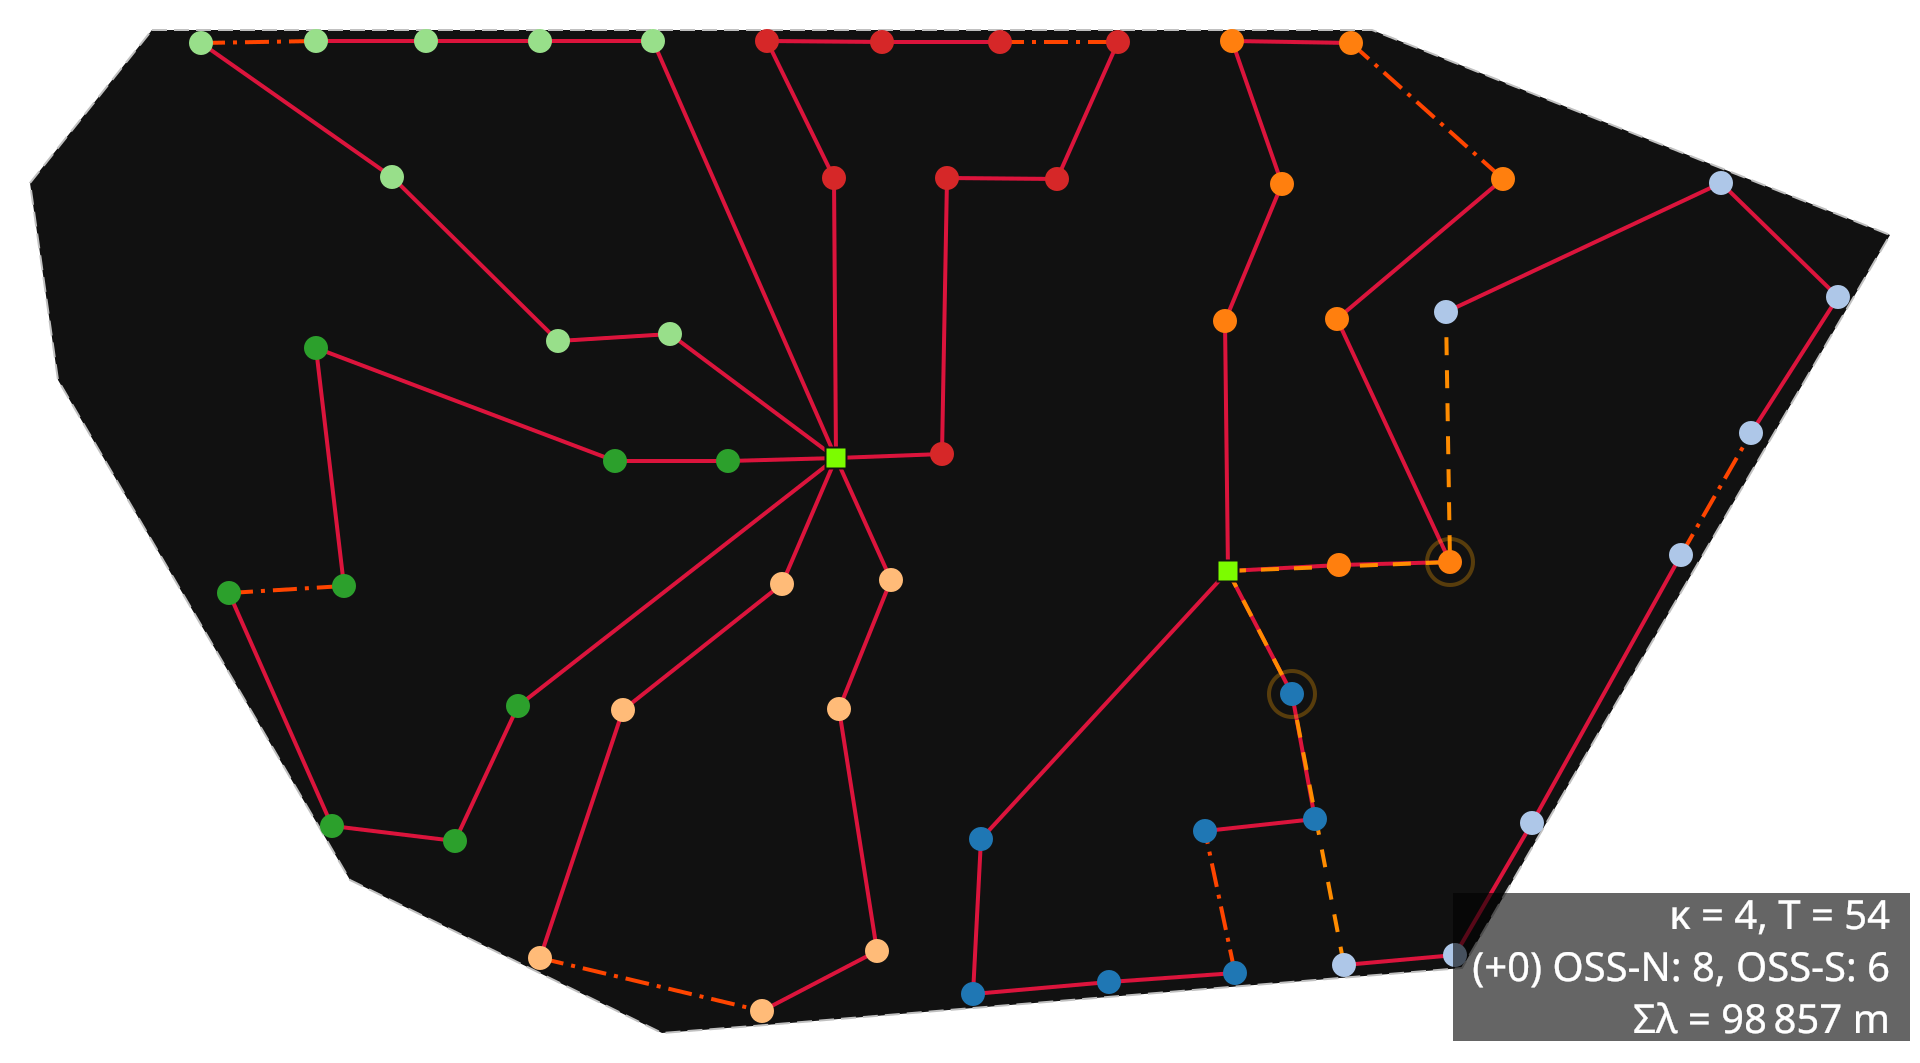

In [10]:
print('validate_topology:', validate_topology(S_clustered) or 'OK')
print('cross-root rings:', cross_root_rings(S_clustered))

G_clustered = PathFinder(G_from_S(S_clustered, A), planar=P, A=A).create_detours()
print('validate_routeset:', validate_routeset(G_clustered) or 'OK')

svgplot(G_clustered)

### 7. What the guarantee costs

Both solutions ran with the same time limit and the same options; only the clustering differs. The clustered run is the longer one, and that difference is the price of the partition — the same price the meta-heuristics pay on every multi-substation instance, here made visible.

In [11]:
for label, S, G in (
    ('unclustered', S_plain, G_plain),
    ('clustered', S_clustered, G_clustered),
):
    print(
        f'{label:>12}: {G.size(weight='length'):>9_.0f} m'
        f'   cross-root rings: {len(cross_root_rings(S))}'
    )

 unclustered:    93_569 m   cross-root rings: 2
   clustered:    98_857 m   cross-root rings: 0


### Summary

- [clusterize()](../autoapi/optiwindnet/clustering/index.rst#optiwindnet.clustering.clusterize) partitions the terminals into one cluster per substation.
- The meta-heuristics call it **automatically** on every multi-root instance, because they can only solve single-depot problems. The partition is chosen from a distance proxy before optimization and never reconsidered, which is a large part of why their multi-substation results trail their single-substation ones.
- The MILP does **not** cluster: it assigns terminals to substations as part of the optimization, and therefore usually finds a shorter network — but its ringed model permits a ring to leave one substation and return to another.
- Calling [clusterize()](../autoapi/optiwindnet/clustering/index.rst#optiwindnet.clustering.clusterize) **manually** and solving one single-root MILP per cluster removes cross-root rings by construction, at the cost of the frozen partition.
- The merged topology is hand-built, so validate it. Routing runs once, on the full instance, after the merge.